In [1]:
from Node import Node
import json
import os
import pickle

#file_paths
g4_path = "2-Build_Graph/data/g4.pkl"
question_path = "InfoSeek/sampled_questions.jsonl"
knn_path = "Evaluation/data/knn.jsonl"
oven_path = "InfoSeek/oven_images_sampled"

with open(g4_path, "rb") as f:
    nodes = pickle.load(f)

questions = {}
with open(question_path, "r", encoding="utf-8") as f:
    for line in f:
        line = json.loads(line)
        questions[line["data_id"]] = (line["question"], line["image_id"])

knn = {}
with open(knn_path, "r", encoding="utf-8") as f:
    for line in f:
        line = json.loads(line)
        knn[line["qid"]] = line["knn"]

images = {}
for img in os.listdir(oven_path):
    img_id, ext = img.split(".")
    if ext.lower() not in {"jpg", "jpeg"}:
        raise ValueError(f"Not image: {img}")
    images[img_id] = f"{oven_path}/{img}"


In [2]:
from LLM.qwen3_vl_reranker import Qwen3VLReranker

model = Qwen3VLReranker(model_name_or_path="Qwen/Qwen3-VL-Reranker-2B")

c:\Users\HP\Desktop\Projects\MMNodeRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 625/625 [00:00<00:00, 4724.10it/s]


In [3]:
import random
random_qid = random.choice(list(questions.keys()))
question = questions[random_qid][0]
img_path = images[questions[random_qid][1]]
query = {"text": question, "image": img_path}
neighbors = knn[random_qid]
neighbors_content = []
for nei in neighbors:
    if "V" in nei:
        nei_content = {"image": nodes[nei].content}
    else:
        nei_content = {"text": nodes[nei].content}
    neighbors_content.append(nei_content)
inputs = {
    "instruction": "Retrieve images or text relevant to the user's query.",
    "query": query,
    "documents": neighbors_content,
}

What is the closest upper taxonomy of this insect?


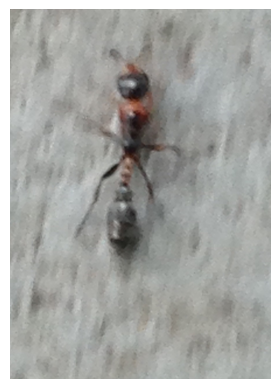

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
print(question)
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [5]:
scores = model.process(inputs)
print(scores)

[0.56640625, 0.33203125, 0.314453125, 0.357421875, 0.447265625, 0.35546875, 0.41796875, 0.439453125, 0.28125, 0.255859375, 0.373046875, 0.2431640625, 0.259765625, 0.33984375, 0.25390625, 0.400390625]


Rank: 0
Score: 0.56640625
Pseudomyrmex gracilis, also known as the graceful twig ant, Mexican twig ant, slender twig ant, or elongated twig ant, is a large, slender species native to Mexico and arid parts of the US. The workers are about 8 - 10 (mm) in length and generally wasp-like in appearance and style of movement. Worker ants are bi-colored; the head and gaster are dark, while the antennae, mouthparts, thorax and legs are dull orange with dark shading. They often may be seen on vegetation, foraging for live insects or collecting honeydew from sap-sucking insects.If the colony ever finds themselves without a queen, the worker ants form dominance hierarchies by boxing with their antennae. This leads to a couple high ranking individuals to lay eggs until a new queen returns. Volker S. Schmid; Martin Kaltenpoth; Erhard Strohm & Jürgen Heinze (2013) ""Worker self-restraint and policing maintain the queen’s reproductive monopoly in a pseudomyrmecine ant" pp. 1University of Florida
-----

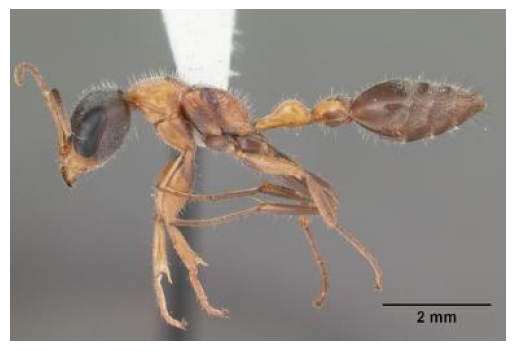

------------------------------
Rank: 10
Score: 0.314453125
Pseudomyrmex gracilis worker ants often may be seen on vegetation, foraging for live insects or collecting honeydew from sap-sucking insects.
------------------------------
Rank: 11
Score: 0.28125
The superfamily Ichneumonoidea comprises one extinct and three extant families, notably including Ichneumonidae and Braconidae, which are the two largest families within the order Hymenoptera. The group is estimated to contain up to 100,000 species, many of which remain undescribed.
------------------------------
Rank: 12
Score: 0.259765625
Artiopods have been considered closely related to chelicerates, which include horseshoe crabs and arachnids, as part of a clade called Arachnomorpha. Alternatively, others consider artiopods to be more closely related to Mandibulata, which contains insects, crustaceans, and myriapods, as part of a clade called Antennulata.
------------------------------
Rank: 13
Score: 0.255859375


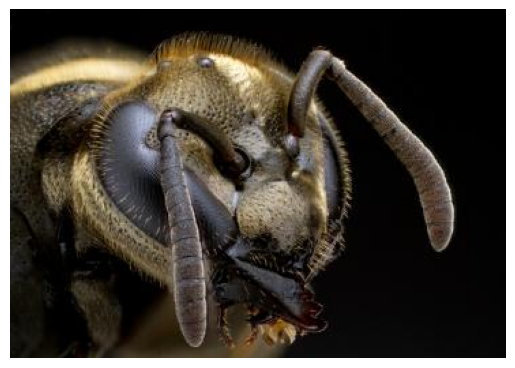

------------------------------
Rank: 14
Score: 0.25390625
Forficula auricularia, also known as the common earwig or European earwig, is an omnivorous insect belonging to the family Forficulidae.
------------------------------
Rank: 15
Score: 0.2431640625
In the subfamily Coccinellinae, members of the tribe Halyziini and the genus Tythaspis are mycophagous.
------------------------------


In [6]:
def sort_by_floats(strings, floats):
    paired = list(zip(strings, floats))
    paired.sort(key=lambda x: x[1], reverse=True)  # sort by float

    sorted_strings, sorted_floats = zip(*paired)
    return list(sorted_strings), list(sorted_floats)

sorted_neighbors, sorted_scores = sort_by_floats(neighbors_content, scores)
for i in range(len(sorted_neighbors)):
    print(f"Rank: {i}")
    print(f"Score: {sorted_scores[i]}")
    content = sorted_neighbors[i]
    if "text" in content:
        print(content["text"])
    if "image" in content:
        plt.imshow(Image.open(content["image"]))
        plt.axis("off")
        plt.show()
    print("-"*30)